In [1]:
from metab_processing.metab_travlr_config import PROJECT_DATA_DIR, DATA_DIR as METAB_DATA_DIR

DATA_DIR = f'{METAB_DATA_DIR}/GSE208253'

In [4]:
RAW_DATA_DIR = DATA_DIR + '/GSE208253_RAW'

In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



SAMPLES = [
    ('6339631', 's1'),
    ('6339632', 's2'),
    ('6339633', 's3'),
    ('6339634', 's4'),
    ('6339635', 's5'),
    ('6339636', 's6'),
    ('6339637', 's7'),
    ('6339638', 's8'),
    ('6339639', 's9'),
    ('6339640', 's10'),
    ('6339641', 's11'),
    ('6339642', 's12'),
]

def load_visium_sample(gsm_id, sample_name):
    adata = sc.read_10x_h5(
        f'{RAW_DATA_DIR}/GSM{gsm_id}_{sample_name}_filtered_feature_bc_matrix.h5'
    )
    adata.var_names_make_unique()  # fix duplicate gene names
    
    positions = pd.read_csv(
        f'{RAW_DATA_DIR}/GSM{gsm_id}_{sample_name}_tissue_positions_list.csv',
        header=None,
        names=['barcode','in_tissue','array_row','array_col','pixel_row','pixel_col']
    )
    positions = positions.drop_duplicates(subset='barcode')
    positions = positions.set_index('barcode')
    
    adata = adata[adata.obs_names.isin(positions[positions['in_tissue']==1].index)]
    adata = adata[~adata.obs_names.duplicated()]
    
    adata.obs = adata.obs.join(positions)
    adata.obsm['spatial'] = adata.obs[['pixel_col','pixel_row']].values
    adata.obs['sample'] = sample_name
    adata.obs_names = [f'{sample_name}_{bc}' for bc in adata.obs_names]
    return adata

# Load and concatenate
adatas = [load_visium_sample(gsm_id, name) for gsm_id, name in SAMPLES]
adata_all = sc.concat(adatas, label='sample', keys=[s[1] for s in SAMPLES])

print(adata_all)
print(adata_all.obs['sample'].value_counts())

/global/home/users/fosterangus/.conda/envs/harreman/lib/python3.12/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/global/home/users/fosterangus/.conda/envs/harreman/lib/python3.12/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/global/home/users/fosterangus/.conda/envs/harreman/lib/python3.12/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


KeyboardInterrupt: 

/tmp/ipykernel_2423709/210670698.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_s, spot_size=150, ax=axes[i], show=False, title=sample_name)
/tmp/ipykernel_2423709/210670698.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_s, spot_size=150, ax=axes[i], show=False, title=sample_name)
/tmp/ipykernel_2423709/210670698.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_s, spot_size=150, ax=axes[i], show=False, title=sample_name)
/tmp/ipykernel_2423709/210670698.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_s, spot_size=150, ax=axes[i], show=False, title=sample_name)
/tmp/ipykernel_2423709/210670698.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_s, spot_size=150, ax=axes[i], show=False, title=sample_name)
/tmp/ipykernel_2423709/210670698.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.s

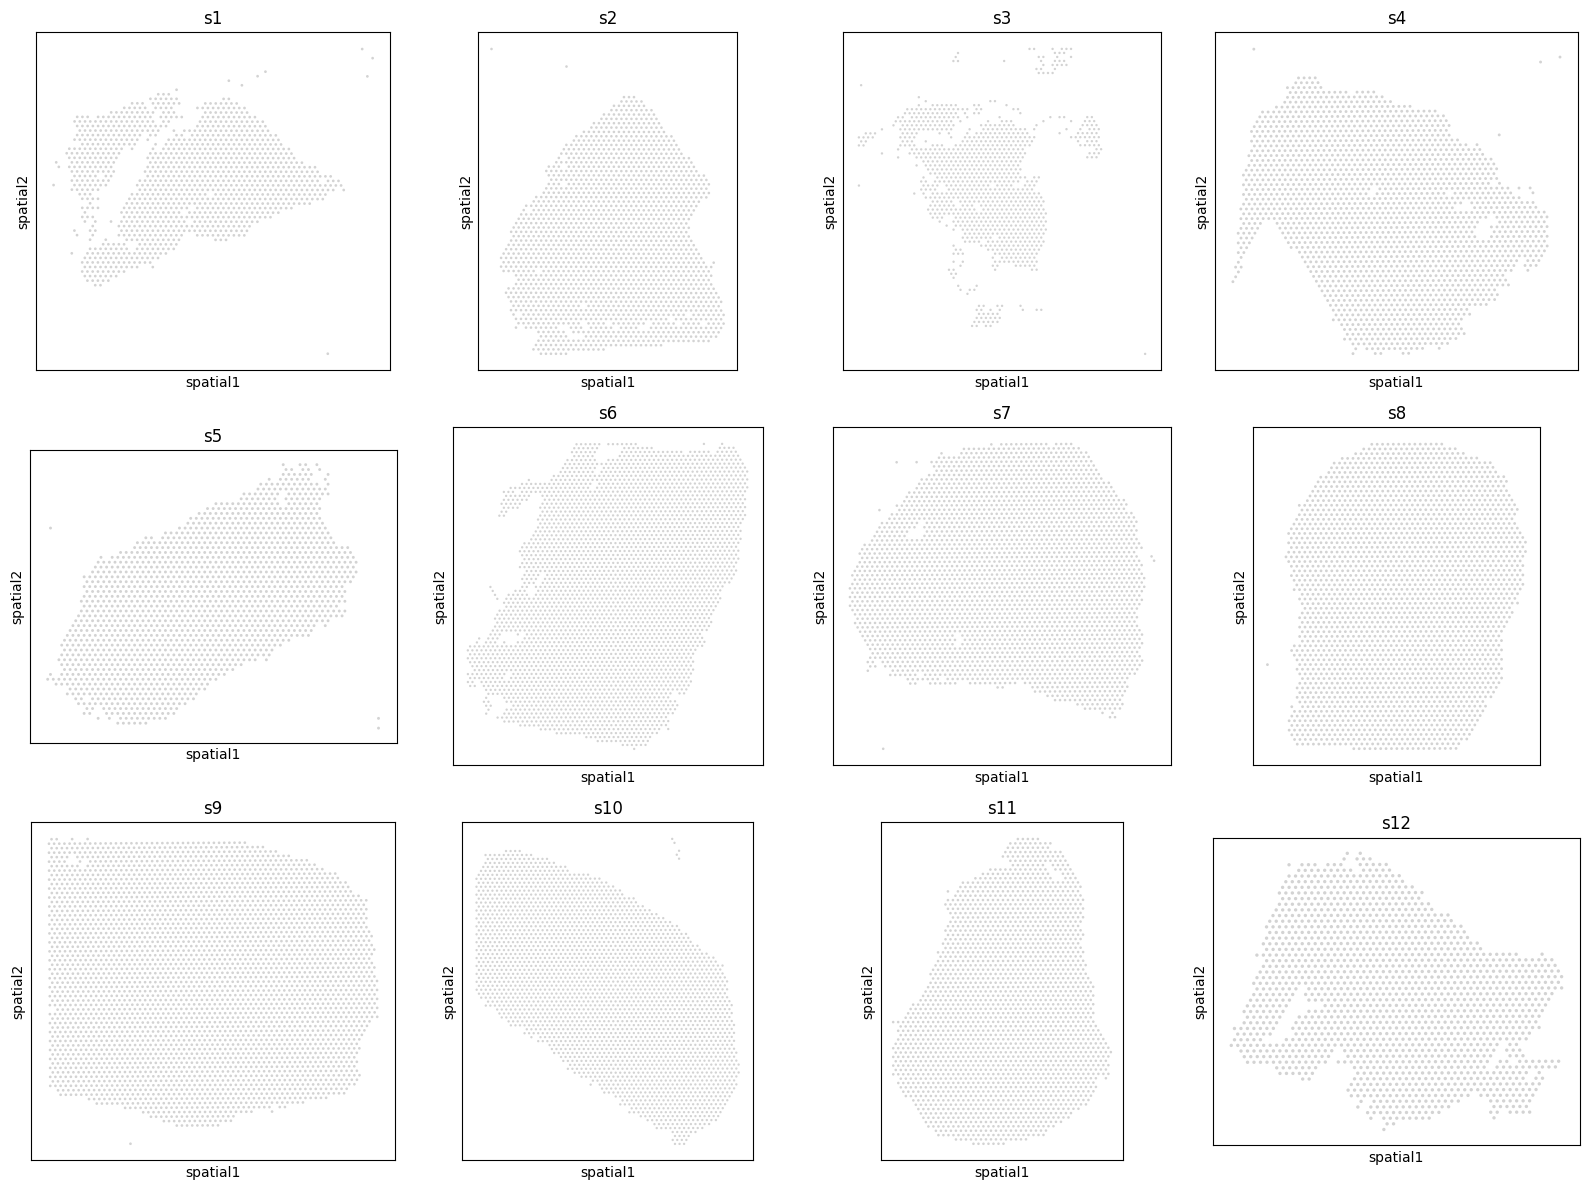

In [3]:
# Plot all samples
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, (gsm_id, sample_name) in enumerate(SAMPLES):
    adata_s = adata_all[adata_all.obs['sample'] == sample_name].copy()
    sc.pl.spatial(adata_s, spot_size=150, ax=axes[i], show=False, title=sample_name)

plt.tight_layout()
plt.show();

In [2]:
adata_all.write_h5ad(f'{DATA_DIR}/adata.h5ad')

NameError: name 'adata_all' is not defined

In [5]:
import harreman
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")

In [6]:
adata = sc.read_h5ad(f'{DATA_DIR}/adata.h5ad')
adata.layers['counts'] = adata.X
adata

AnnData object with n_obs × n_vars = 26371 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'pixel_row', 'pixel_col', 'sample', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI', 'leiden_scVI_colors', 'neighbors', 'sample_colors', 'umap'
    obsm: 'X_scVI', 'X_umap', 'spatial'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [7]:
# Make sure raw counts are stored
adata.layers['counts'] = adata.X.copy()

# Normalize and log-transform, store as a layer
adata.X = adata.layers['counts'].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers['log_norm'] = adata.X.copy()

# Restore raw counts as X
adata.X = adata.layers['counts'].copy()

In [8]:
sample_col = 'sample'
n_genes_expr = 50
genes_to_keep = np.zeros(adata.shape[1], dtype=bool)

for sample in adata.obs[sample_col].unique():
    adata_sample = adata[adata.obs[sample_col] == sample]
    expressed = np.array((adata_sample.X > 0).sum(axis=0)).flatten()
    genes_to_keep |= expressed >= n_genes_expr

adata = adata[:, genes_to_keep].copy()

In [9]:
adata

AnnData object with n_obs × n_vars = 26371 × 14997
    obs: 'in_tissue', 'array_row', 'array_col', 'pixel_row', 'pixel_col', 'sample', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI', 'leiden_scVI_colors', 'neighbors', 'sample_colors', 'umap', 'log1p'
    obsm: 'X_scVI', 'X_umap', 'spatial'
    layers: 'counts', 'log_norm'
    obsp: 'connectivities', 'distances'

In [10]:
t_cell_markers = ['CD3D', 'CD3E', 'CD3G', 'CD8A', 'CD8B', 'CD4', 'FOXP3']
sc.tl.score_genes(adata, gene_list=t_cell_markers, score_name='t_cell_score')

In [10]:
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)
# sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
# adata = adata[:, adata.var.highly_variable]

In [11]:
adata

AnnData object with n_obs × n_vars = 26371 × 14997
    obs: 'in_tissue', 'array_row', 'array_col', 'pixel_row', 'pixel_col', 'sample', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 't_cell_score'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI', 'leiden_scVI_colors', 'neighbors', 'sample_colors', 'umap', 'log1p'
    obsm: 'X_scVI', 'X_umap', 'spatial'
    layers: 'counts', 'log_norm'
    obsp: 'connectivities', 'distances'

In [9]:
# sc.tl.pca(adata, svd_solver='arpack')
# sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

In [ ]:
# sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)

In [ ]:
# # Step 1: Calculate UMAP for each sample
# sub_adatas = [adata[adata.obs['sample'] == s].copy() for s in adata.obs['sample'].unique()]
# for sub in sub_adatas:
#     sc.pp.neighbors(sub, n_pcs=30)
#     sc.tl.umap(sub)

In [ ]:
# # Step 2: Plot t_cell_score for each sample
# for sub in sub_adatas:
#     sc.pl.umap(sub, color='t_cell_score', cmap='Reds', vmin=0, title=sub.obs['sample'].iloc[0])

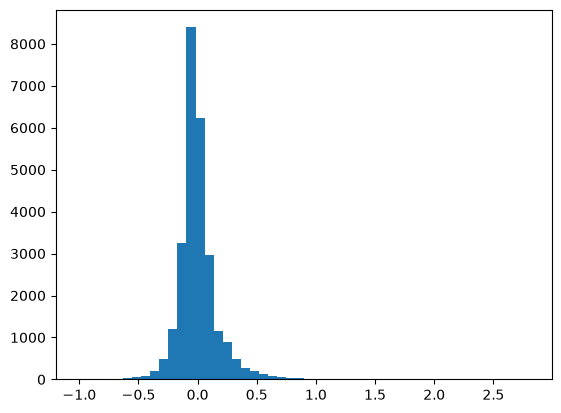

In [12]:
plt.hist(adata.obs['t_cell_score'], bins=50);

In [13]:
adata.obs['cell_type'] = 'other'  # this creates the column

# Add 'T cell' as a category before assigning
adata.obs['cell_type'] = adata.obs['cell_type'].astype(str)  # convert out of categorical
adata.obs.loc[adata.obs['t_cell_score'] > 0.3, 'cell_type'] = 'T cell'
adata.obs['cell_type'] = adata.obs['cell_type'].astype('category')  # back to categorical

print(adata.obs['cell_type'].value_counts())

cell_type
other     25070
T cell     1301
Name: count, dtype: int64


In [14]:
# Start fresh with transporter database only
harreman.pp.extract_interaction_db(
    adata,
    species='human',
    database='transporter',   # metabolic transporters only, not LR pairs
    extracellular_only=True,
    verbose=True
)

# Check how many genes are in the database
print("Genes in transporter database:")
db_key = adata.uns['database_varm_key']
print(adata.varm[db_key].shape)

# Rerun gene filtering
harreman.tl.apply_gene_filtering(
    adata,
    layer_key='counts',
    model='bernoulli',
    autocorrelation_filt=False,
    verbose=True
)

# Check what's actually stored
print(type(adata.uns['expression_filt']))
print(adata.uns['expression_filt'])
print(adata.uns['de_filt'])

# Check the database key and what genes are in it
db_key = adata.uns['database_varm_key']
print(f"\nDatabase key: {db_key}")
print(f"Database shape: {adata.varm[db_key].shape}")

# Get the transporter genes that are in your adata
import pandas as pd
db = pd.DataFrame(adata.varm[db_key], index=adata.var_names)
transporter_genes = db.index[db.any(axis=1)].tolist()
print(f"\nTransporter genes in your dataset: {len(transporter_genes)}")
print(transporter_genes[:30])

# Check their expression
import numpy as np
if len(transporter_genes) > 0:
    expr = np.array(adata[:, transporter_genes].layers['counts'].sum(axis=0)).flatten()
    n_spots_expressed = (np.array(adata[:, transporter_genes].layers['counts'].toarray()) > 0).sum(axis=0)
    gene_stats = pd.DataFrame({
        'gene': transporter_genes,
        'total_counts': expr,
        'n_spots': n_spots_expressed
    }).sort_values('total_counts', ascending=False)
    print("\nTop 20 transporter genes by expression:")
    print(gene_stats.head(20))
    print(f"\nGenes expressed in >100 spots: {(gene_stats['n_spots'] > 100).sum()}")
    print(f"Genes expressed in >50 spots: {(gene_stats['n_spots'] > 50).sum()}")
    print(f"Genes expressed in >10 spots: {(gene_stats['n_spots'] > 10).sum()}")

Extracting interaction database...
Finished extracting interaction database in 0.481 seconds
Genes in transporter database:
(14997, 212)
Applying gene filtering...
Finished applying gene filtering in 0.000 seconds
<class 'bool'>
False
False

Database key: database
Database shape: (14997, 212)

Transporter genes in your dataset: 183
['SLC2A5', 'SLC9A1', 'MFSD2A', 'SLC2A1', 'SLC6A9', 'SLC44A3', 'SLC16A1', 'SLC27A3', 'SLC39A1', 'RHBG', 'CRABP2', 'SLC19A2', 'SLC41A1', 'SLC26A9', 'SLC30A1', 'FLVCR1', 'SLC5A6', 'SLC30A6', 'SLC8A1', 'SLC1A4', 'SLC20A1', 'SLC35F5', 'SLC40A1', 'SLC39A10', 'SLC11A1', 'SLC4A3', 'SLC6A11', 'SLC6A6', 'SLC4A7', 'SLC26A6']

Top 20 transporter genes by expression:
        gene  total_counts  n_spots
68     FABP5     1496175.0    25070
75      AQP3      162860.0    19423
131     RHCG       87497.0    17066
104  SLC38A2       77843.0    19170
3     SLC2A1       72353.0    17961
53      TAP1       56939.0    17186
91    SLC3A2       44742.0    16090
33      RBP1       40

In [15]:
# Recompute KNN graph (in case it needs refreshing)
harreman.tl.compute_knn_graph(
    adata,
    compute_neighbors_on_key='spatial',
    n_neighbors=5,
    weighted_graph=False,
    sample_key='sample',
    verbose=True
)

# Compute gene pairs with transporter database only
harreman.tl.compute_gene_pairs(adata, ct_specific=False, verbose=True)
print(f"Gene pairs to test: {len(adata.uns.get('gene_pairs', []))}")

# Run communication
harreman.tl.compute_cell_communication(
    adata,
    model='bernoulli',
    M=200,
    test='both',
    layer_key_p_test='counts',
    layer_key_np_test='log_norm',
    verbose=True
)

# Check results before filtering
df = adata.uns['ccc_results']['cell_com_df_gp'].copy()
print(f"\nTotal pairs tested: {len(df)}")
print(f"Non-zero C scores: {(df['C_np'] != 0).sum()}")
print(f"\nTop 10 by C score:")
print(df.sort_values('C_np', ascending=False).head(10)[['Gene 1', 'Gene 2', 'C_np', 'FDR_np']])

Computing the neighborhood graph...
Restricting graph within samples using 'sample'...


100%|██████████| 12/12 [00:00<00:00, 111.33it/s]


Computing the weights...
Finished computing the KNN graph in 0.303 seconds
Computing gene pairs...
Finished computing gene pairs in 0.152 seconds
Gene pairs to test: 900
Starting cell-cell communication analysis...
Running the parametric test...


OutOfMemoryError: CUDA out of memory. Tried to allocate 182.00 MiB. GPU 0 has a total capacity of 23.55 GiB of which 102.12 MiB is free. Process 3669327 has 23.14 GiB memory in use. Including non-PyTorch memory, this process has 300.00 MiB memory in use. Of the allocated memory 39.26 MiB is allocated by PyTorch, and 22.74 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [17]:
# Check what the gene_pairs actually contain
gp = adata.uns['gene_pairs']
gp_per_metabolite = adata.uns['gene_pairs_per_metabolite']

print(f"Total gene pairs: {len(gp)}")
print(f"Total metabolites with pairs: {len(gp_per_metabolite)}")
print(f"\nMetabolites covered:")
for met in list(gp_per_metabolite.keys())[:20]:
    print(f"  {met}")

# Check importer/exporter info stored by harreman
print("\nKeys related to import/export:")
print(adata.uns.get('importer', 'not found'))
print(adata.uns.get('exporter', 'not found'))
print(adata.uns.get('import_export', 'not found'))

# Look at actual pair structure
print("\nFirst 10 gene pairs and their structure:")
for i, pair in enumerate(gp[:10]):
    print(f"  {pair}")

Total gene pairs: 900
Total metabolites with pairs: 212

Metabolites covered:
  D-Glucose
  D-Galactose
  D-Mannose
  Glucosamine
  Docosahexaenoic acid
  D-Xylose
  L-Glutamine
  L-Alanine
  L-Asparagine
  L-Cysteine
  L-Histidine
  L-Serine
  Glycine
  L-Methionine
  L-Proline
  L-Threonine
  L-Lactate
  Pyruvate
  Ketone bodies
  Nicotinate

Keys related to import/export:
Empty DataFrame
Columns: [IMPORT0, IMPORT1, IMPORT2, IMPORT3, IMPORT4, IMPORT5, IMPORT6, IMPORT7, IMPORT8, IMPORT9, IMPORT10, IMPORT11, IMPORT12, IMPORT13, IMPORT14, IMPORT15, IMPORT16, IMPORT17, IMPORT18, IMPORT19, IMPORT20, IMPORT21, IMPORT22, IMPORT23, IMPORT24, IMPORT25, IMPORT26, IMPORT27, IMPORT28, IMPORT29, IMPORT30, IMPORT31, IMPORT32, IMPORT33, IMPORT34, IMPORT35, IMPORT36, IMPORT37, IMPORT38, IMPORT39, IMPORT40, IMPORT41, IMPORT42, IMPORT43, IMPORT44, IMPORT45, IMPORT46, IMPORT47, IMPORT48, IMPORT49, IMPORT50, IMPORT51, IMPORT52, IMPORT53, IMPORT54, IMPORT55, IMPORT56, IMPORT57, IMPORT58, IMPORT59, IMPORT

In [18]:
metabolite_pair_counts = {metabolite: len(info['gene_pair']) for metabolite, info in gp_per_metabolite.items()}
print(metabolite_pair_counts)

{'D-Glucose': 55, 'D-Galactose': 10, 'D-Mannose': 6, 'Glucosamine': 3, 'Docosahexaenoic acid': 6, 'D-Xylose': 1, 'L-Glutamine': 153, 'L-Alanine': 45, 'L-Asparagine': 10, 'L-Cysteine': 28, 'L-Histidine': 28, 'L-Serine': 55, 'Glycine': 6, 'L-Methionine': 15, 'L-Proline': 10, 'L-Threonine': 10, 'L-Lactate': 15, 'Pyruvate': 36, 'Ketone bodies': 6, 'Nicotinate': 6, 'Butyrate': 1, 'L-Glutamate': 21, 'L-Aspartate': 3, 'D-Aspartate': 1, 'L-Cystine': 6, 'Zinc': 91, 'Magnesium': 6, 'Iron': 45, 'Copper': 6, 'Cobalt': 3, 'Cadmium': 3, 'Barium': 1, 'Nickel': 1, 'Manganese': 6, 'Acetyl-L-Carnitine': 1, 'L-Carnitine': 6, 'Sodium': 91, 'Hydrogen carbonate': 1, 'Eicosanoid': 1, 'Prostaglandins': 3, '5-Aminolevulinic acid': 1, 'Dipeptides': 3, 'Protons': 1, 'Tripeptides': 3, 'Carnosine': 1, 'Acetate': 3, 'L-Leucine': 28, 'L-Arginine': 28, 'Fatty acid': 21, 'Kynurenine': 3, 'Creatine': 3, 'GABA': 10, 'Choline': 21, 'Triiodothyronine': 1, 'Thyroxine': 1, 'L-Phenylalanine': 21, 'L-Tyrosine': 10, 'L-Tryptop

In [30]:
harreman.tl.select_significant_interactions(adata, test='non-parametric', threshold=0.05)

In [31]:
adata.uns['ccc_results']['cell_com_df_gp_sig']

,Gene 1,Gene 2,C_p,Z,Z_pval,Z_FDR,C_norm_p,C_np,pval_np,FDR_np,C_norm_np,selected
0,SLC2A6,SLC2A11,4009.482162,6.032479,8.073189e-10,1.453174e-09,0.038018,383.605122,0.004975,0.007981,0.059904,True
2,SLC2A4,SLC2A4,1443.786294,2.873464,2.029987e-03,2.429505e-03,0.038390,40.243334,0.004975,0.007981,0.031479,True
3,SLC5A10,SLC2A11,2531.779772,4.146403,1.688695e-05,2.427836e-05,0.036218,110.046536,0.019900,0.028429,0.063359,True
5,SLC2A9,SLC2A12,1897.082048,2.852881,2.166239e-03,2.578856e-03,0.017790,155.780716,0.034826,0.047999,0.030760,True
7,SLC2A12,SLC2A6,1550.731562,2.333158,9.819930e-03,1.103363e-02,0.024491,188.928283,0.004975,0.007981,0.118364,True
...,...,...,...,...,...,...,...,...,...,...,...,...
894,SLC47A2,SLC47A2,5328.680993,10.605291,1.407936e-26,4.728145e-26,0.046319,1742.352829,0.004975,0.007981,0.145871,True
896,MFSD2A,MFSD2A,8242.673939,16.404801,8.835213e-61,7.163686e-60,0.068675,6651.411668,0.004975,0.007981,0.214653,True
897,RHBG,RHBG,2405.979220,4.788447,8.403829e-07,1.324597e-06,0.034785,90.787725,0.004975,0.007981,0.044935,True
898,RHCG,RHCG,22232.636728,44.248018,0.000000e+00,0.000000e+00,0.179303,242641.244152,0.004975,0.007981,0.757407,True


In [32]:
counts_per_sample = adata.obs.groupby(['sample', 'cell_type']).size().unstack(fill_value=0)
good_samples = counts_per_sample[counts_per_sample['T cell'] >= 20].index.tolist()
print("Samples kept:", good_samples)

adata_sub = adata[adata.obs['sample'].isin(good_samples)].copy()

Samples kept: ['s1', 's2', 's3', 's4', 's7', 's8', 's9', 's10']


In [33]:
# Get the significant gene pairs from step 5 to focus on
cell_communication_df = adata_sub.uns['ccc_results']['cell_com_df_gp_sig'].copy()
gene_pairs_filt = list(zip(cell_communication_df['Gene 1'], cell_communication_df['Gene 2']))

# Compute cell-type-specific gene pairs
harreman.tl.compute_gene_pairs(adata, cell_type_key='cell_type', verbose=True)

# Run Test 8 — cell-type-specific metabolite crosstalk
harreman.tl.compute_ct_cell_communication(
    adata_sub,
    model='bernoulli',
    cell_type_key='cell_type',
    M=1000,
    test='both',
    layer_key_p_test='counts',
    layer_key_np_test='log_norm',
    subset_gene_pairs=gene_pairs_filt,
    fix_gp=False,           # False = Test 8 (metabolite level)
    verbose=True
)

harreman.tl.select_significant_interactions(
    adata_sub,
    test='non-parametric',
    ct_aware=True,
    threshold=0.05
)

Computing gene pairs...
Finished computing gene pairs in 0.963 seconds
Starting cell type-aware cell-cell communication analysis...
Running the parametric test...
Running the non-parametric test...


Permutation test: 100%|██████████| 1000/1000 [07:55<00:00,  2.10it/s]


Non-parametric test finished.
Obtaining cell type-aware communication results...
Finished computing cell type-aware cell-cell communication analysis in 478.778 seconds


In [34]:
# Get the metabolite-level results
results = adata_sub.uns['ct_ccc_results']['cell_com_df_m'].copy()

# Filter to interactions involving T cells
t_cell_results = results[
    (results['Cell Type 1'] == 'T cell') | (results['Cell Type 2'] == 'T cell')
]

# Show significant ones
sig_t_cell = t_cell_results[t_cell_results['selected'] == True]
print(sig_t_cell[['Cell Type 1', 'Cell Type 2', 'metabolite']].sort_values('metabolite'))

    Cell Type 1 Cell Type 2                 metabolite
194      T cell       other    2-Hydroxychlorpropamide
195      T cell       other      25-Hydroxycholesterol
200      T cell       other       4'-Hydroxydiclofenac
9        T cell      T cell       4'-Hydroxydiclofenac
202      T cell       other        4-ene-Valproic acid
..          ...         ...                        ...
375      T cell       other                       Zinc
184      T cell      T cell                       Zinc
376      T cell       other    all-trans-Retinoic acid
377      T cell       other  alpha-Ketoisovaleric acid
379      T cell       other           alpha-Tocopherol

[202 rows x 3 columns]


In [35]:

adata_sub.uns['ct_ccc_results'].keys()

dict_keys(['p', 'np', 'cell_com_df_gp', 'cell_com_df_m', 'cell_com_df_gp_sig', 'cell_com_df_m_sig'])

In [36]:
adata_sub.uns['ct_ccc_results']['cell_com_df_gp_sig']

,Cell Type 1,Cell Type 2,Gene 1,Gene 2,C_p,Z,Z_pval,Z_FDR,C_norm_p,C_np,pval_np,FDR_np,C_norm_np,selected
19,T cell,T cell,SLC2A1,SLC2A10,1.610328,0.042569,4.830225e-01,6.291497e-01,0.001919,84.567879,0.014985,0.028445,0.037941,True
31,T cell,T cell,SLC38A1,SLC7A5,45.159130,1.193784,1.162812e-01,2.048516e-01,0.034762,599.747131,0.000999,0.002638,1.052961,True
34,T cell,T cell,SLC16A10,SLC16A10,50.958836,1.347100,8.897409e-02,1.653172e-01,0.089661,152.588257,0.027972,0.048882,7.558444,True
35,T cell,T cell,SLC16A10,SLC7A5,0.420556,0.011117,4.955649e-01,6.397079e-01,0.000740,15.769769,0.024975,0.043998,0.781154,True
40,T cell,T cell,SLC3A2,SLC1A5,-75.287140,-1.990220,9.767166e-01,9.999974e-01,-0.090863,99.214500,0.009990,0.019949,0.041242,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1952,other,other,SLC27A3,SLC27A3,2134.006348,7.692373,7.221520e-15,4.828313e-14,0.031263,1344.539185,0.000999,0.002638,0.126099,True
1954,other,other,SLC47A2,SLC47A2,3227.890869,11.635458,1.360624e-31,1.635252e-30,0.051658,841.671448,0.000999,0.002638,0.131625,True
1955,other,other,MFSD2A,MFSD2A,4856.255371,17.505163,6.542566e-69,2.136148e-67,0.071806,4186.645508,0.000999,0.002638,0.214145,True
1957,other,other,RHCG,RHCG,13150.276367,47.402312,0.000000e+00,0.000000e+00,0.182337,120760.726562,0.000999,0.002638,0.734154,True


In [38]:
adata.uns['ccc_results']['cell_com_df_gp_sig']

,Gene 1,Gene 2,C_p,Z,Z_pval,Z_FDR,C_norm_p,C_np,pval_np,FDR_np,C_norm_np,selected
0,SLC2A6,SLC2A11,4009.482162,6.032479,8.073189e-10,1.453174e-09,0.038018,383.605122,0.004975,0.007981,0.059904,True
2,SLC2A4,SLC2A4,1443.786294,2.873464,2.029987e-03,2.429505e-03,0.038390,40.243334,0.004975,0.007981,0.031479,True
3,SLC5A10,SLC2A11,2531.779772,4.146403,1.688695e-05,2.427836e-05,0.036218,110.046536,0.019900,0.028429,0.063359,True
5,SLC2A9,SLC2A12,1897.082048,2.852881,2.166239e-03,2.578856e-03,0.017790,155.780716,0.034826,0.047999,0.030760,True
7,SLC2A12,SLC2A6,1550.731562,2.333158,9.819930e-03,1.103363e-02,0.024491,188.928283,0.004975,0.007981,0.118364,True
...,...,...,...,...,...,...,...,...,...,...,...,...
894,SLC47A2,SLC47A2,5328.680993,10.605291,1.407936e-26,4.728145e-26,0.046319,1742.352829,0.004975,0.007981,0.145871,True
896,MFSD2A,MFSD2A,8242.673939,16.404801,8.835213e-61,7.163686e-60,0.068675,6651.411668,0.004975,0.007981,0.214653,True
897,RHBG,RHBG,2405.979220,4.788447,8.403829e-07,1.324597e-06,0.034785,90.787725,0.004975,0.007981,0.044935,True
898,RHCG,RHCG,22232.636728,44.248018,0.000000e+00,0.000000e+00,0.179303,242641.244152,0.004975,0.007981,0.757407,True


In [ ]:
adata.uns['ccc_results']['cell_com_df_gp_sig'].to_csv(f'{DATA_DIR}/[ccc_results][cell_com_df_gp_sig].csv')

In [ ]:
adata_sub.uns['ct_ccc_results']['cell_com_df_m'].to_csv(f'{DATA_DIR}/[ct_ccc_results][cell_com_df_m].csv')

In [ ]:
adata_sub.uns['ct_ccc_results']['cell_com_df_m'].to_csv(f'{DATA_DIR}/[ct_ccc_results][cell_com_df_gp_sig].csv')

In [45]:
def save_adata(adata, filename):
    backup = dict(adata.uns)
    for k, v in backup.items():
        if isinstance(v, pd.DataFrame):
            adata.uns[k] = v.fillna('')
        elif isinstance(v, dict):
            adata.uns[k] = {("__".join(map(str, key)) if isinstance(key, tuple) else str(key)): val for key, val in v.items()}
    adata.write_h5ad(filename)
    adata.uns.clear()
    adata.uns.update(backup)

In [ ]:
save_adata(adata_sub, f"{DATA_DIR}/processed_adata_sub.h5ad")

In [4]:
import numpy as np

# Inspect the problematic uns entry
print(adata_sub.uns['import_export'])
print(adata_sub.uns['import_export'].dtypes)

NameError: name 'adata_sub' is not defined

In [40]:
import pandas as pd
import numpy as np

def scan_uns(d, path="uns"):
    if isinstance(d, dict):
        for k, v in d.items():
            scan_uns(v, f"{path}['{k}']")
    elif isinstance(d, pd.DataFrame):
        for col in d.columns:
            series = d[col]
            bad = series.apply(lambda x: x is not None and not isinstance(x, (str, np.floating, float)) and not (isinstance(x, float) and np.isnan(x)))
            # simpler: just report types
            types = series.apply(type).unique()
            if len(types) > 1 or (len(types) == 1 and types[0] not in (str, type(None))):
                print(f"{path}['{col}'] dtype={series.dtype}, types found={types}")

scan_uns(adata_sub.uns)

uns['import_export']['IMPORT_EXPORT0'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]
uns['import_export']['IMPORT_EXPORT1'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]
uns['import_export']['IMPORT_EXPORT2'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]
uns['import_export']['IMPORT_EXPORT3'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]
uns['import_export']['IMPORT_EXPORT4'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]
uns['import_export']['IMPORT_EXPORT5'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]
uns['import_export']['IMPORT_EXPORT7'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]
uns['import_export']['IMPORT_EXPORT8'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]
uns['import_export']['IMPORT_EXPORT9'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]
uns['import_export']['IMPORT_EXPORT10'] dtype=object, types found=[<class 'str'> <class 'NoneType'>]

In [42]:
adata_sub.uns['import_export']

,IMPORT_EXPORT0,IMPORT_EXPORT1,IMPORT_EXPORT2,IMPORT_EXPORT3,IMPORT_EXPORT4,IMPORT_EXPORT5,IMPORT_EXPORT6,IMPORT_EXPORT7,IMPORT_EXPORT8,IMPORT_EXPORT9,...,IMPORT_EXPORT231,IMPORT_EXPORT232,IMPORT_EXPORT233,IMPORT_EXPORT234,IMPORT_EXPORT235,IMPORT_EXPORT236,IMPORT_EXPORT237,IMPORT_EXPORT238,IMPORT_EXPORT239,IMPORT_EXPORT240
0,SLC2A1,SLC2A1,SLC2A1,SLC2A1,SLC2A1,SLC2A3,SLC16A10,SLC16A10,SLC1A5,SLC16A10,...,None,None,None,SLC23A2,SLC27A3,SLC43A3,SLC47A1,None,MFSD2A,RHBG
1,SLC2A10,SLC2A10,SLC2A3,SLC2A4,SLC2A3,None,SLC1A5,SLC1A5,SLC38A1,SLC1A5,...,None,None,None,None,SLC27A4,None,SLC47A2,None,None,RHCG
2,SLC2A11,SLC2A3,SLC5A10,None,SLC2A4,None,SLC36A2,SLC36A1,SLC38A2,SLC38A1,...,None,None,None,None,None,None,None,None,None,None
3,SLC2A12,SLC2A8,None,None,None,None,SLC38A1,SLC36A2,SLC43A1,SLC38A2,...,None,None,None,None,None,None,None,None,None,None
4,SLC2A3,None,None,None,None,None,SLC38A2,SLC38A1,None,SLC43A2,...,None,None,None,None,None,None,None,None,None,None
5,SLC2A4,None,None,None,None,None,SLC38A5,SLC38A2,None,SLC7A11,...,None,None,None,None,None,None,None,None,None,None
6,SLC2A6,None,None,None,None,None,SLC38A6,SLC38A6,None,SLC7A8,...,None,None,None,None,None,None,None,None,None,None
7,SLC2A8,None,None,None,None,None,SLC38A7,SLC6A15,None,None,...,None,None,None,None,None,None,None,None,None,None
8,SLC2A9,None,None,None,None,None,SLC38A9,SLC7A8,None,None,...,None,None,None,None,None,None,None,None,None,None
9,SLC5A10,None,None,None,None,None,SLC3A2,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [47]:
dat = sc.read_h5ad(f"{DATA_DIR}/processed_adata_sub.h5ad")

In [48]:
dat

AnnData object with n_obs × n_vars = 17693 × 14997
    obs: 'in_tissue', 'array_row', 'array_col', 'pixel_row', 'pixel_col', 'sample', 't_cell_score', 'cell_type'
    uns: 'D', 'autocorrelation_filt', 'ccc_results', 'cell_type_key', 'cell_type_pairs', 'cell_types', 'cells', 'center_counts_for_np_test', 'ct_ccc_results', 'database', 'database_varm_key', 'de_filt', 'exporter', 'expression_filt', 'fix_ct', 'gene_pair_dict', 'gene_pairs', 'gene_pairs_ind', 'gene_pairs_ind_per_ct_pair', 'gene_pairs_per_ct_pair', 'gene_pairs_per_ct_pair_ind', 'gene_pairs_per_metabolite', 'genes', 'heterodimer_info', 'importer', 'layer_key_np_test', 'layer_key_p_test', 'lc_zs', 'log1p', 'mean', 'metabolite_database', 'model', 'num_metabolites', 'sample_key', 'species'
    obsm: 'spatial'
    varm: 'database'
    layers: 'counts', 'log_norm'
    obsp: 'distances', 'weights'

In [49]:
dat.uns['gene_pairs_per_metabolite']

{'(3a,5b,7a)-23-Carboxy-7-hydroxy-24-norcholan-3-yl-b-D-Glucopyranosiduronic acid': {'gene_pair': array([['ABCC3', 'SLCO4A1'],
         ['SLCO4A1', 'SLCO4A1'],
         ['SLCO1B3', 'SLCO4A1'],
         ['ABCC3', 'ABCC3'],
         ['SLCO1B3', 'ABCC3'],
         ['SLCO1B3', 'SLCO1B3']], dtype=object),
  'gene_type': array([['IMP-EXP', 'IMP-EXP'],
         ['IMP-EXP', 'IMP-EXP'],
         ['IMP-EXP', 'IMP-EXP'],
         ['IMP-EXP', 'IMP-EXP'],
         ['IMP-EXP', 'IMP-EXP'],
         ['IMP-EXP', 'IMP-EXP']], dtype=object)},
 '17a-Ethynylestradiol': {'gene_pair': array([['ABCB1', 'ABCC2'],
         ['ABCC2', 'ABCC2'],
         ['ABCB1', 'ABCB1']], dtype=object),
  'gene_type': array([['IMP-EXP', 'IMP-EXP'],
         ['IMP-EXP', 'IMP-EXP'],
         ['IMP-EXP', 'IMP-EXP']], dtype=object)},
 '1b,3a,12a-Trihydroxy-5b-cholanoic acid': {'gene_pair': array([['ABCC3', 'SLCO4A1'],
         ['SLCO4A1', 'SLCO4A1'],
         ['SLCO1B3', 'SLCO4A1'],
         ['ABCC3', 'ABCC3'],
         ['SLCO1B3',